# INEP - Média de alunos por turma

Média de Alunos por Turma da Educação Básica - Ensino Infantil (Creche, Pré-Escola), Ensino Fundamental e Ensino Médio, por Localização e Dependência Administrativa - Brasil, Regiões Geográficas e Unidades da Federação - 2024																									

## Carregando o conjunto de dados

In [21]:
import pandas as pd

atu = pd.read_excel('datasets/ATU_BRASIL_REGIOES_UFS_2024.xlsx', skiprows=8)

In [20]:
atu

,ug,loc,da,ti,tf,tm
0,Brasil,Total,Total,15.4,22.4,28.9
1,Brasil,Urbana,Total,15.6,23.8,29.6
2,Brasil,Rural,Total,14.3,16,21
3,Brasil,Total,Federal,12.3,26,30.5
4,Brasil,Urbana,Federal,12.6,26,30.6
...,...,...,...,...,...,...
586,Distrito Federal,Urbana,Pública,19,23.1,28.8
587,Distrito Federal,Rural,Pública,16.3,19.9,22.3
588,NaN,NaN,NaN,NaN,NaN,NaN
589,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
atu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 591 entries, 0 to 590
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ug      588 non-null    object
 1   loc     588 non-null    object
 2   da      588 non-null    object
 3   ti      588 non-null    object
 4   tf      588 non-null    object
 5   tm      588 non-null    object
dtypes: object(6)
memory usage: 27.8+ KB




**Obs.:** Todas as colunas estão sendo identificadas como Object

Antes de resolver esse problema vamos selecionar as colunas
Unidade Geográfica, Localização, Dependência Administrativa, Total Infantil, Total Fundamental e Total Médio para efetuar a análise.

In [22]:
atu = atu.iloc[:, [1,2,3,4,7,20]]
atu

,UNIDGEO,NO_CATEGORIA,NO_DEPENDENCIA,ED_INF_CAT_0,FUN_CAT_0,MED_CAT_0
0,Brasil,Total,Total,15.4,22.4,28.9
1,Brasil,Urbana,Total,15.6,23.8,29.6
2,Brasil,Rural,Total,14.3,16,21
3,Brasil,Total,Federal,12.3,26,30.5
4,Brasil,Urbana,Federal,12.6,26,30.6
...,...,...,...,...,...,...
586,Distrito Federal,Urbana,Pública,19,23.1,28.8
587,Distrito Federal,Rural,Pública,16.3,19.9,22.3
588,NaN,NaN,NaN,NaN,NaN,NaN
589,NaN,NaN,NaN,NaN,NaN,NaN


Dicionário:
- ug: Unidade Geográfica
- loc: Localização
- da: Dependência Administrativa
- ti: Total Ensino Infantil
- tf: Total Ensino Fundamental
- tm: Total Ensino Médio

In [23]:
colunas = ["ug", "loc", "da", "ti", "tf", "tm"]
atu.columns = colunas

In [24]:
atu

,ug,loc,da,ti,tf,tm
0,Brasil,Total,Total,15.4,22.4,28.9
1,Brasil,Urbana,Total,15.6,23.8,29.6
2,Brasil,Rural,Total,14.3,16,21
3,Brasil,Total,Federal,12.3,26,30.5
4,Brasil,Urbana,Federal,12.6,26,30.6
...,...,...,...,...,...,...
586,Distrito Federal,Urbana,Pública,19,23.1,28.8
587,Distrito Federal,Rural,Pública,16.3,19.9,22.3
588,NaN,NaN,NaN,NaN,NaN,NaN
589,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
atu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 591 entries, 0 to 590
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ug      588 non-null    object
 1   loc     588 non-null    object
 2   da      588 non-null    object
 3   ti      588 non-null    object
 4   tf      588 non-null    object
 5   tm      588 non-null    object
dtypes: object(6)
memory usage: 27.8+ KB


Vamos considerar que os valores ausentes indicam que não existem escolas com aquele nível de ensino na região.

In [ ]:
df = atu.replace('--', 0)

C:\Users\Deyvid\AppData\Local\Temp\ipykernel_25736\3170459046.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = atu.replace('--', 0)


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 591 entries, 0 to 590
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ug      588 non-null    object 
 1   loc     588 non-null    object 
 2   da      588 non-null    object 
 3   ti      588 non-null    float64
 4   tf      588 non-null    float64
 5   tm      588 non-null    float64
dtypes: float64(3), object(3)
memory usage: 27.8+ KB


In [38]:
df.groupby('ug')[['ti', 'tf', 'tm']].median().round(2)

,ti,tf,tm
ug,,,
Acre,14.20,20.80,22.40
Alagoas,16.70,20.00,33.10
Amapá,12.90,17.40,27.20
Amazonas,12.90,21.20,26.50
Bahia,13.95,20.95,27.90
Brasil,14.35,22.40,28.45
Ceará,14.95,20.10,31.30
Centro-Oeste,15.30,23.50,27.75
Distrito Federal,16.30,22.30,28.90


In [36]:
df.groupby('loc')[['ti', 'tf', 'tm']].median()

,ti,tf,tm
loc,,,
Rural,12.45,15.1,22.0
Total,15.30,22.2,27.9
Urbana,15.80,24.4,28.7


In [39]:
pd.pivot_table(df, values="tf", index="ug", columns="da", aggfunc="median")

da,Estadual,Federal,Municipal,Privada,Pública,Total
ug,,,,,,
Acre,21.2,25.0,18.7,20.8,20.2,20.2
Alagoas,29.6,0.0,24.5,17.5,25.0,23.2
Amapá,21.5,0.0,20.1,17.1,20.9,20.5
Amazonas,28.3,29.5,20.3,17.6,22.2,21.8
Bahia,28.5,26.2,21.3,17.2,21.6,20.6
Brasil,26.1,26.0,22.4,19.0,23.3,22.4
Ceará,17.7,28.9,23.6,18.1,23.5,22.1
Centro-Oeste,26.0,30.3,23.6,19.0,24.6,23.4
Distrito Federal,22.9,31.5,NaN,20.6,22.9,22.2


## Visualização dos dados

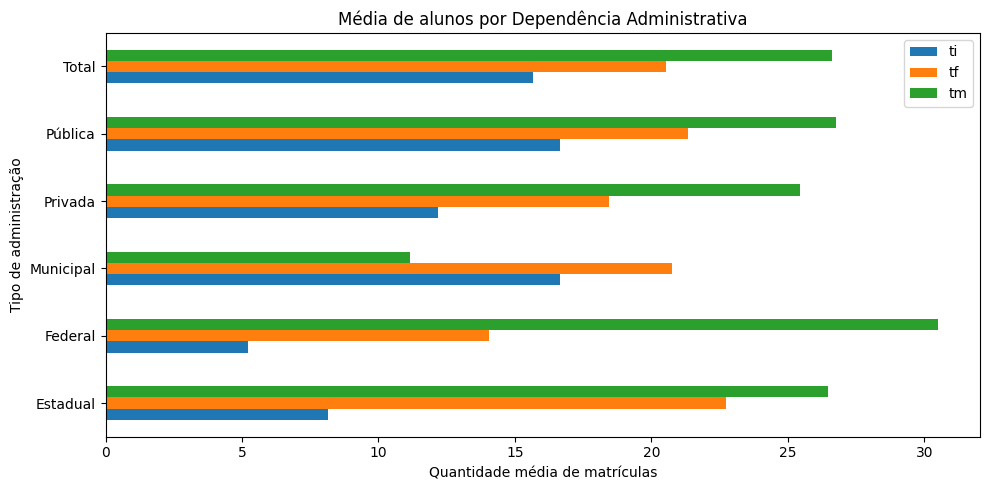

In [41]:
import matplotlib.pyplot as plt
 
df.groupby("da")[["ti", "tf", "tm"]].mean().plot(kind="barh", figsize=(10, 5))
plt.title("Média de alunos por Dependência Administrativa")
plt.xlabel("Quantidade média de matrículas")
plt.ylabel("Tipo de administração")
plt.tight_layout()
plt.show()

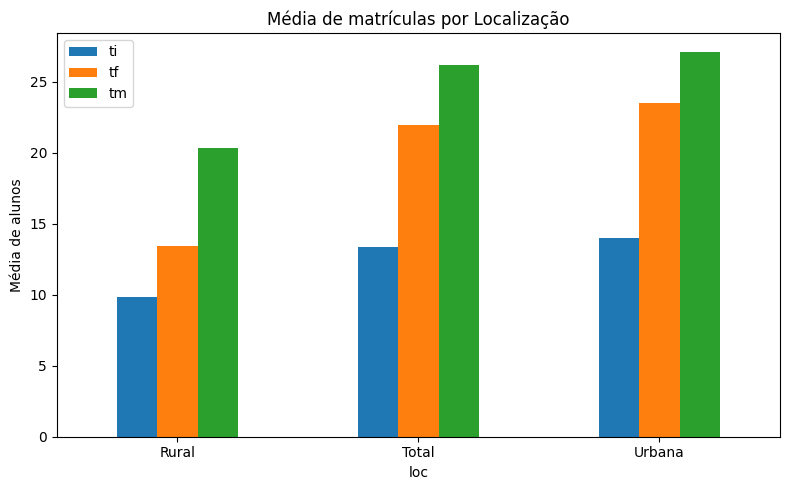

In [43]:
df.groupby("loc")[["ti", "tf", "tm"]].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Média de matrículas por Localização")
plt.ylabel("Média de alunos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

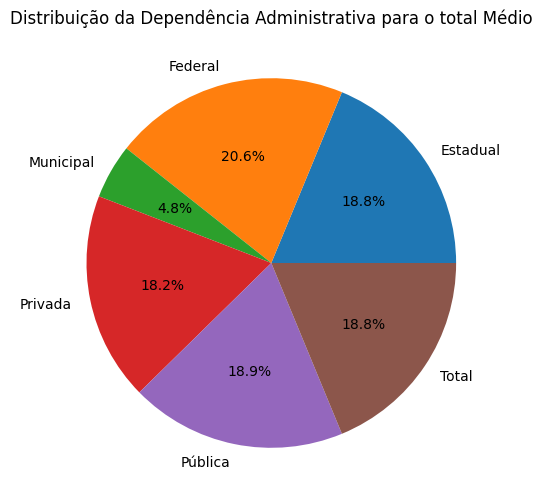

In [46]:
df.groupby("da")["tm"].median().plot.pie(autopct="%1.1f%%", figsize=(6, 6), ylabel="")
plt.title("Distribuição da Dependência Administrativa para o total Médio")
plt.show()

In [49]:
df.to_csv("atu-modificado.csv", sep=';', decimal=',')